In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
g3_df = pd.read_csv(DATA_RAW / "fe_groups/g3.csv")
g4_df = pd.read_csv(DATA_RAW / "fe_groups/g4.csv")
g6_df = pd.read_csv(DATA_RAW / "fe_groups/g6.csv")

g4_cols = ["tconst"] + [col for col in g4_df.columns if col.startswith("g4_")]
g6_cols = ["tconst"] + [col for col in g6_df.columns if col.startswith("g6_")]

model_df = (
    g3_df
    .merge(g4_df[g4_cols], on="tconst", how="left")
    .merge(g6_df[g6_cols], on="tconst", how="left")
)

print(model_df.shape)

model_df.head()

(2255, 65)


,Unnamed: 0.1,Unnamed: 0,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,...,g4_local_60d_mode_genre,g4_local_60d_mode_genre_count,g4_matches_local_60d_mode_genre,g6_local_avg_budget_20d,g6_local_median_budget_20d,g6_local_max_budget_20d,g6_num_larger_budget_competitors_20d,g6_budget_percentile_local_20d,g6_budget_vs_local_avg_ratio,g6_budget_vs_local_median_ratio
0,0,1112,tt1311067,Halloween II,2009.0,https://www.the-numbers.com/movie/Halloween-II,True,NaN,7676836.0,1217.0,...,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,1,689,tt0816462,Conan the Barbarian,2011.0,https://www.the-numbers.com/movie/Conan-the-Ba...,True,NaN,9479373.0,1358.0,...,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,2,1974,tt4731008,The Wild Life,2016.0,https://www.the-numbers.com/movie/Wild-Life-The,True,NaN,4001400.0,1140.0,...,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,980,tt1160419,Dune: Part One,2021.0,https://www.the-numbers.com/movie/Dune,True,NaN,6025091.0,915.0,...,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,4,1291,tt1540128,Playing for Keeps,2012.0,https://www.the-numbers.com/movie/Playing-for-...,True,NaN,1406300.0,1148.0,...,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [3]:
target = "log_opening_weekend_gross"

num_group_features = [
    'g6_local_avg_budget_20d',
    'g6_local_median_budget_20d',
    'g6_local_max_budget_20d',
    'g6_num_larger_budget_competitors_20d',
    'g6_budget_percentile_local_20d',
    'g6_budget_vs_local_avg_ratio',
    'g6_budget_vs_local_median_ratio',

    'g4_local_60d_mode_genre_count',

    'g3_distance_from_nearest_seasonal_peak',
    'g3_nearby_general_movies_20d_count',
    'g3_nearby_similar_genre_movies_20d_count',
    'g3_nearby_general_similar_budget_movies_20d_count',
    'g3_nearby_similar_genre_similar_budget_movies_20d_count',
    'g3_budget_x_distance_from_peak'
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + num_group_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

cat_group_feature = [
    'g3_nearest_seasonal_peak_category',
    'g4_local_60d_mode_genre',
    'g4_matches_local_60d_mode_genre'
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
 ] + people_features + cat_group_feature

In [4]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 35)
(2255,)


In [5]:
y.skew()

np.float64(-1.5649493879014558)

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
y_test_dollars = np.expm1(y_test)

In [82]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [83]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [84]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.627402451340509,
 'mae_log': 0.8017701739184797,
 'mae_dollars': 12304645.133966882}

In [85]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.6720969958587845,
 'mae_log': 0.7458666980442893,
 'mae_dollars': 11788700.865463896}

In [86]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.627402,0.801770,1.230465e+07
1,XGBoost Baseline,0.672097,0.745867,1.178870e+07


In [87]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [88]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [89]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

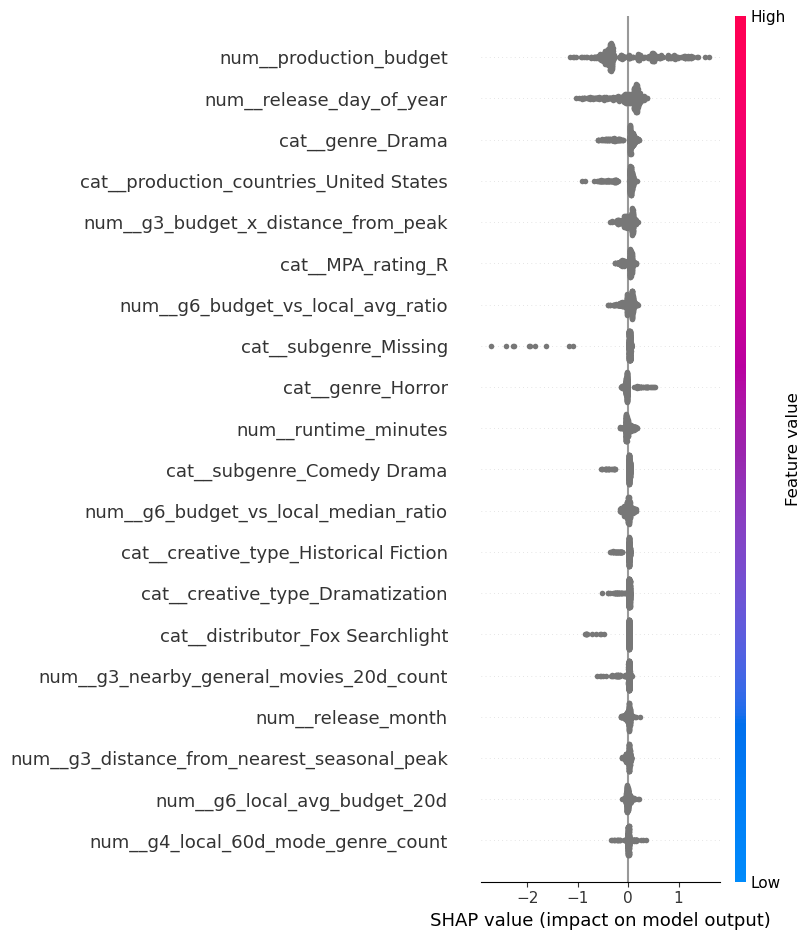

In [90]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

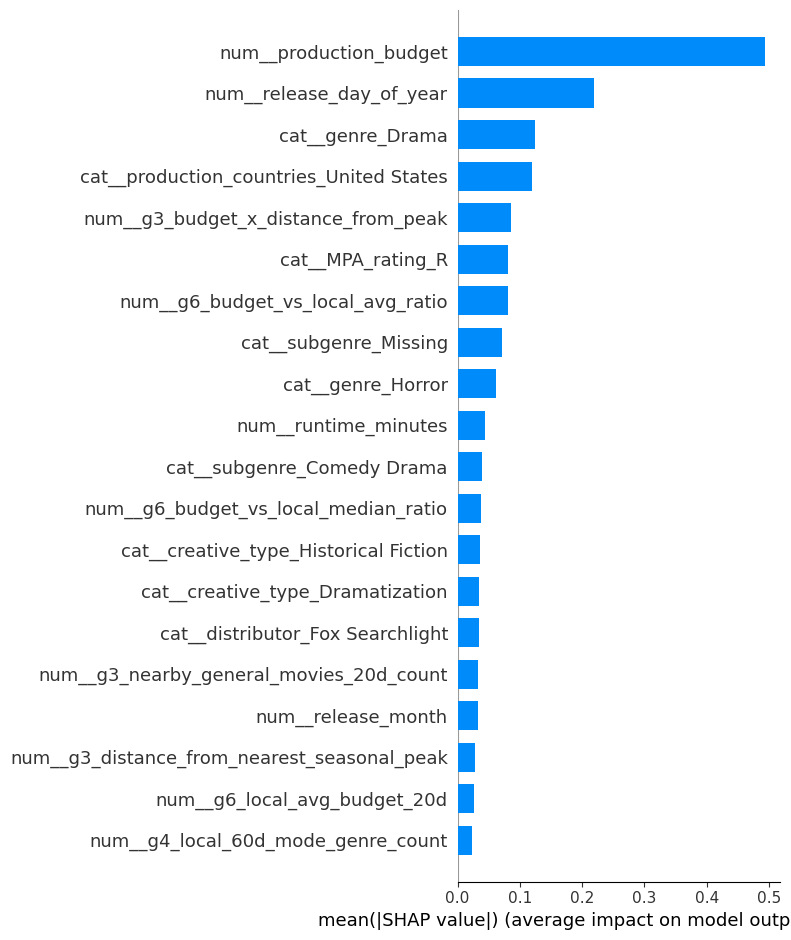

In [91]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [92]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g6_local_avg_budget_20d,g6_local_median_budget_20d,g6_local_max_budget_20d,g6_num_larger_budget_competitors_20d,g6_budget_percentile_local_20d,g6_budget_vs_local_avg_ratio,...,actor_2,actor_3,g3_nearest_seasonal_peak_category,g4_local_60d_mode_genre,g4_matches_local_60d_mode_genre,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1847,400000000.0,181.0,4,116,2.388889e+07,14000000.0,50000000.0,0.0,1.000000,16.744186,...,nm0262635,nm0749263,spring,Adventure,0,19.693568,18.652815,3.571150e+08,126128888.0,2.309861e+08
1718,200000000.0,120.0,2,47,4.278571e+07,50000000.0,69000000.0,0.0,1.000000,4.674457,...,nm0430107,nm2143282,spring,Drama,0,19.123798,18.130350,2.020040e+08,74801624.0,1.272023e+08
1620,160000000.0,123.0,3,76,9.333333e+07,120000000.0,185000000.0,1.0,0.777778,1.714286,...,nm11380870,nm3592451,spring,Action,0,18.978870,17.816269,1.747506e+08,54639572.0,1.201110e+08
1619,160000000.0,123.0,3,76,9.333333e+07,120000000.0,185000000.0,1.0,0.777778,1.714286,...,nm1405398,nm1812656,spring,Action,0,18.978870,17.816269,1.747506e+08,54639572.0,1.201110e+08
2126,145000000.0,114.0,7,202,1.099286e+08,100000000.0,290000000.0,2.0,0.714286,1.319038,...,nm0331516,nm4793987,summer,Action,0,18.903243,17.697212,1.620220e+08,48506688.0,1.135154e+08
2204,200000000.0,100.0,6,166,5.770000e+07,50000000.0,100000000.0,0.0,1.000000,3.466205,...,nm1638321,nm10143485,summer,Action,0,18.853772,17.851126,1.542017e+08,56577712.0,9.762396e+07
1422,74000000.0,91.0,7,191,5.273846e+07,31000000.0,155000000.0,3.0,0.692308,1.403151,...,nm0358316,nm0000474,summer,Action,0,18.566670,17.193007,1.157184e+08,29297316.0,8.642109e+07
1423,74000000.0,91.0,7,191,5.273846e+07,31000000.0,155000000.0,3.0,0.692308,1.403151,...,nm1853544,nm0000273,summer,Action,0,18.566670,17.193007,1.157184e+08,29297316.0,8.642109e+07
1832,175000000.0,124.0,3,67,6.012500e+07,53500000.0,129000000.0,0.0,1.000000,2.910603,...,nm0000168,nm0578853,spring,Drama,0,18.848777,18.183924,1.534334e+08,78918304.0,7.451512e+07
203,115000000.0,139.0,5,139,5.790909e+07,45000000.0,110000000.0,0.0,1.000000,1.985871,...,nm0000204,nm0000191,summer,Comedy,0,18.501669,17.344530,1.084358e+08,34090528.0,7.434531e+07


In [93]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/combo_346_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/combo_346_xgb_test_errors.csv",
    index=False
)